# Repeated Measures with Random Intercepts

**Topics:** Longitudinal Data, Random Effects, Within-Subject Correlation

## Overview

Analyze repeated measurements within subjects using GAMM with random intercepts.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from aurora.models.gamm import fit_gamm

sns.set_style('whitegrid')
np.random.seed(42)

## Generate Longitudinal Data

In [2]:
n_subjects = 30
n_timepoints = 5
n = n_subjects * n_timepoints

# Subject-level random effects
subject_effects = np.random.randn(n_subjects) * 3

data = []
for subj in range(n_subjects):
    for time in range(n_timepoints):
        treatment = subj >= n_subjects // 2  # Half treated
        
        # Outcome: baseline + time_effect + treatment_effect + subject_effect + noise
        y = (
            50  # baseline
            + 2 * time  # time trend
            + 5 * treatment  # treatment effect
            + 1.5 * treatment * time  # treatment × time interaction
            + subject_effects[subj]  # random intercept
            + np.random.randn() * 2  # residual noise
        )
        
        data.append({
            'subject': subj,
            'time': time,
            'treatment': int(treatment),
            'y': y
        })

df = pd.DataFrame(data)

print(f"Generated {n} observations")
print(f"  {n_subjects} subjects × {n_timepoints} timepoints")
print(f"\nTreatment groups: {df.groupby('treatment')['subject'].nunique().to_dict()}")

Generated 150 observations
  30 subjects × 5 timepoints

Treatment groups: {0: 15, 1: 15}


## Visualize Trajectories

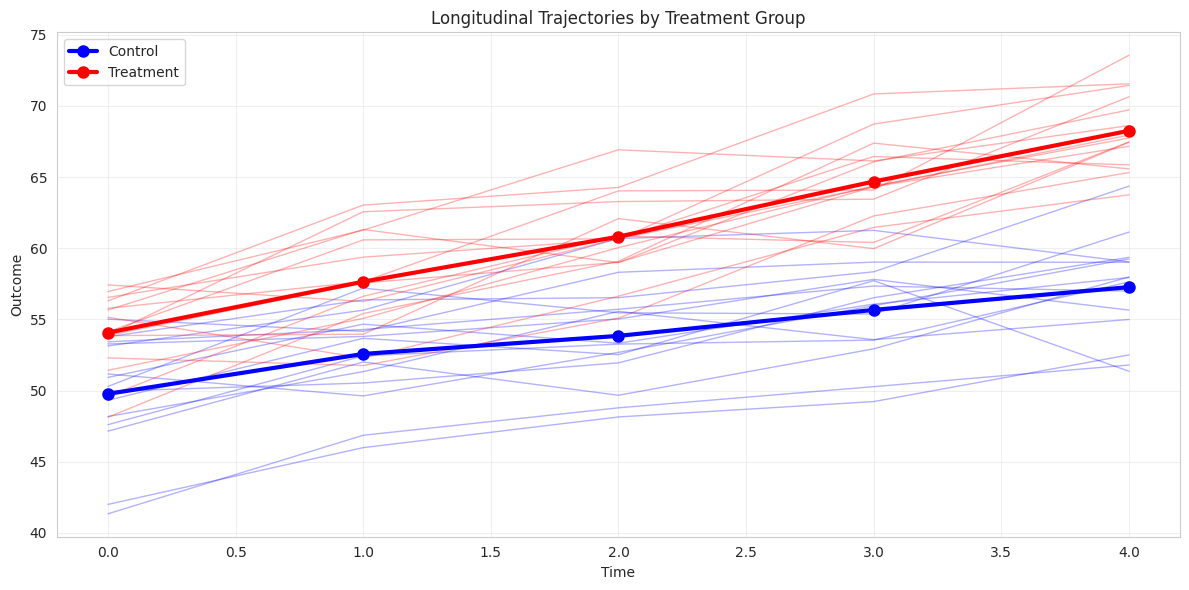

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual trajectories
for subj in df['subject'].unique():
    subj_data = df[df['subject'] == subj]
    treatment = subj_data['treatment'].iloc[0]
    color = 'red' if treatment else 'blue'
    alpha = 0.3
    ax.plot(subj_data['time'], subj_data['y'], 
            color=color, alpha=alpha, linewidth=1)

# Plot group means
for treatment in [0, 1]:
    group_mean = df[df['treatment']==treatment].groupby('time')['y'].mean()
    color = 'red' if treatment else 'blue'
    label = 'Treatment' if treatment else 'Control'
    ax.plot(group_mean.index, group_mean.values, 
            color=color, linewidth=3, marker='o', markersize=8, label=label)

ax.set_xlabel('Time')
ax.set_ylabel('Outcome')
ax.set_title('Longitudinal Trajectories by Treatment Group')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Fit GAMM with Random Intercepts

In [4]:
# Create interaction term in dataframe
df['time_treatment'] = df['time'] * df['treatment']

# Method 1: Using formula mode (recommended)
result = fit_gamm(
    formula='y ~ time + treatment + time_treatment + (1 | subject)',
    data=df,
    family='gaussian',
    covariance='identity'
)

print("GAMM Results:")
print(f"\nFixed Effects:")
fixed_names = ['Intercept', 'Time', 'Treatment', 'Time×Treatment']
for i, name in enumerate(fixed_names):
    print(f"  {name}: {result.beta_parametric[i]:.2f}")

print(f"\nRandom Effects:")
subject_var = result.variance_components[0, 0]  # Extract scalar from 2D array
print(f"  Subject variance: {subject_var:.2f}")
print(f"  Residual variance: {result.residual_variance:.2f}")
print(f"  Subject SD: {np.sqrt(subject_var):.2f}")
print(f"  Residual SD: {np.sqrt(result.residual_variance):.2f}")

print(f"\nModel: Converged={result.converged}, Iterations={result.n_iterations}")

GAMM Results:

Fixed Effects:
  Intercept: 50.20
  Time: 1.81
  Treatment: 3.81
  Time×Treatment: 1.73

Random Effects:
  Subject variance: 6.77
  Residual variance: 3.95
  Subject SD: 2.60
  Residual SD: 1.99

Model: Converged=True, Iterations=7


**Next:**  
- `04_longitudinal/02_random_slopes.ipynb` - Subject-specific slopes  
- `04_longitudinal/03_nested_random_effects.ipynb` - Multi-level structure  